# Training Performance Audit (TensorBoard)

This notebook audits model-training dynamics from TensorBoard logs in
`./artifacts/tensorboard_logs`.

It provides:
- programmatic scalar extraction,
- training vs validation loss curves,
- overfitting / underfitting diagnostics,
- learning-rate schedule checks,
- early-stopping consistency checks.


In [10]:
from __future__ import annotations

from pathlib import Path
import re
import json
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Ensure plots render inside notebook output.
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass

# Unified project plotting style
try:
    from energy_trading.visualization.style import apply_geo_style
except ModuleNotFoundError:
    import sys
    from pathlib import Path

    _root = Path.cwd().resolve()
    if _root.name == 'notebooks':
        _root = _root.parent
    _src = _root / 'src'
    if str(_src) not in sys.path:
        sys.path.insert(0, str(_src))
    from energy_trading.visualization.style import apply_geo_style

apply_geo_style()


In [11]:
# Configuration
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent

import sys
SRC_DIR = REPO_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from energy_trading.utils.run_context import resolve_model_run_dirs

TB_LOG_DIR = REPO_ROOT / 'artifacts/tensorboard_logs'
MODEL_RUN_DIRS = resolve_model_run_dirs(repo_root=REPO_ROOT, models=('xgboost', 'tft', 'linear'))

# Focus plots on these target families (editable):
TARGET_FILTER_PATTERNS = [
    r'^da_target_da_price$',
    r'afrr_.*(activation_rate|spread|capacity|activation_price)',
]

print('TB_LOG_DIR:', TB_LOG_DIR)
print('Resolved model run dirs:')
for m, rd in MODEL_RUN_DIRS.items():
    print(f' - {m}: {rd.name}')


TB_LOG_DIR: /Users/leori/Code/energyTrading/artifacts/tensorboard_logs
Resolved model run dirs:
 - xgboost: fulltrain_2026-04-25T17-30-55Z_xgboost
 - tft: fulltrain_2026-04-25T17-30-55Z_tft
 - linear: fulltrain_2026-04-25T17-30-55Z_linear


In [12]:
try:
    from tensorboard.backend.event_processing import event_accumulator
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        'tensorboard is required for this notebook. Install with: pip install tensorboard'
    ) from exc


def pretty_model_label(model: str) -> str:
    m = str(model).strip().lower()
    if m in {'xgboost', 'xgb'}:
        return 'XGBoost'
    if m == 'tft':
        return 'TFT'
    if m == 'linear':
        return 'Linear'
    return str(model)


def pretty_target_label(target: str) -> str:
    t = str(target).lower()
    if 'da_price' in t:
        return 'DA Price'
    if 'activation_rate' in t:
        return 'Activation Rate'
    if 'capacity_price' in t:
        return 'Capacity Price'
    if 'activation_price' in t:
        return 'Activation Price'
    if 'spread' in t:
        return 'Spread'
    # Fallback: strip model/bundle prefixes and title-case.
    for pref in ('xgboost_', 'xgb_', 'tft_', 'linear_', 'da_', 'afrr_', 'target_'):
        t = t.replace(pref, '')
    return t.replace('_', ' ').strip().title()


def pick_run_dir(tb_root: Path, run_id: str | None = None) -> Path:
    if not tb_root.exists():
        raise FileNotFoundError(f'TensorBoard log root not found: {tb_root}')
    if run_id:
        rd = tb_root / run_id
        if not rd.exists():
            raise FileNotFoundError(f'Run directory not found: {rd}')
        return rd
    candidates = sorted([p for p in tb_root.iterdir() if p.is_dir()])
    if not candidates:
        raise FileNotFoundError(f'No run directories found under: {tb_root}')
    return candidates[-1]


def pick_scalar_tag(tags: list[str], patterns: list[str]) -> str | None:
    for pat in patterns:
        rx = re.compile(pat, re.IGNORECASE)
        for t in tags:
            if rx.search(t):
                return t
    return None


def extract_scalars_for_target(target_dir: Path) -> pd.DataFrame:
    ea = event_accumulator.EventAccumulator(str(target_dir), size_guidance={'scalars': 0})
    ea.Reload()
    tags = ea.Tags().get('scalars', [])

    train_tag = pick_scalar_tag(tags, [r'train.*loss.*epoch', r'train.*loss', r'loss/train', r'train_loss'])
    val_tag = pick_scalar_tag(tags, [r'val.*loss.*epoch', r'valid.*loss', r'loss/val', r'val_loss'])
    lr_tag = pick_scalar_tag(tags, [r'learning_rate', r'lr', r'optimizer.*/lr'])

    rows = []
    for split, tag in [('train', train_tag), ('val', val_tag), ('lr', lr_tag)]:
        if tag is None:
            continue
        for e in ea.Scalars(tag):
            rows.append({
                'target': target_dir.name,
                'split': split,
                'tag': tag,
                'step': int(e.step),
                'value': float(e.value),
                'wall_time': float(e.wall_time),
            })

    return pd.DataFrame(rows), {'train_tag': train_tag, 'val_tag': val_tag, 'lr_tag': lr_tag, 'tags': tags}


MIN_POINTS_FOR_CLASSIFICATION = 5


def classify_training(train_vals: np.ndarray, val_vals: np.ndarray) -> str:
    if len(train_vals) < MIN_POINTS_FOR_CLASSIFICATION or len(val_vals) < MIN_POINTS_FOR_CLASSIFICATION:
        return 'Insufficient Data'
    val_best = float(np.min(val_vals))
    val_final = float(val_vals[-1])
    train_final = float(train_vals[-1])
    best_idx = int(np.argmin(val_vals))

    if best_idx < len(val_vals) - 3 and val_final > val_best * 1.05 and train_final <= float(np.min(train_vals[max(0, best_idx-1):])):
        return 'Overfitting Detected'

    tail_n = max(3, int(0.2 * len(val_vals)))
    val_tail = val_vals[-tail_n:]
    if float(np.max(val_tail) - np.min(val_tail)) <= max(1e-8, 0.01 * max(abs(val_final), 1.0)) and val_final > train_final * 0.95:
        return 'Underfitting Suspected'

    if len(val_tail) >= 4:
        diffs = np.diff(val_tail)
        if float(np.std(diffs)) > max(1e-8, 0.05 * max(abs(val_final), 1.0)):
            return 'Unstable'

    return 'Converged'


In [13]:
run_scope = []
for model, run_dir in MODEL_RUN_DIRS.items():
    tb_run_dir = TB_LOG_DIR / run_dir.name
    if not tb_run_dir.exists():
        print(f'[WARN] Missing TensorBoard run dir for model={model}: {tb_run_dir}')
        continue

    target_dirs = sorted([p for p in tb_run_dir.iterdir() if p.is_dir()])
    if not target_dirs:
        print(f'[WARN] No target subdirectories in: {tb_run_dir}')
        continue

    rx_list = [re.compile(p, re.IGNORECASE) for p in TARGET_FILTER_PATTERNS]
    def keep_target(name: str) -> bool:
        return any(rx.search(name) for rx in rx_list)

    target_dirs = [p for p in target_dirs if keep_target(p.name)] or target_dirs
    for td in target_dirs:
        run_scope.append({'model': model, 'run_id': run_dir.name, 'target_dir': td})

run_scope_df = pd.DataFrame(
    [
        {
            'model': r['model'],
            'model_label': pretty_model_label(r['model']),
            'run_id': r['run_id'],
            'target': r['target_dir'].name,
            'target_label': pretty_target_label(r['target_dir'].name),
        }
        for r in run_scope
    ]
)

if run_scope_df.empty:
    raise RuntimeError('No TensorBoard targets found for resolved models. Check artifacts/tensorboard_logs and .env run IDs.')

print('Targets selected:', len(run_scope_df))
display(run_scope_df.sort_values(['model_label', 'target_label']).reset_index(drop=True))


Targets selected: 18


,model,run_id,target
0,linear,fulltrain_2026-04-25T17-30-55Z_linear,linear_afrr_target_afrr_activation_price_vwap_neg
1,linear,fulltrain_2026-04-25T17-30-55Z_linear,linear_afrr_target_afrr_activation_price_vwap_pos
2,linear,fulltrain_2026-04-25T17-30-55Z_linear,linear_afrr_target_afrr_activation_rate_neg
3,linear,fulltrain_2026-04-25T17-30-55Z_linear,linear_afrr_target_afrr_activation_rate_pos
4,linear,fulltrain_2026-04-25T17-30-55Z_linear,linear_afrr_target_afrr_capacity_price_neg
5,linear,fulltrain_2026-04-25T17-30-55Z_linear,linear_afrr_target_afrr_capacity_price_pos
6,tft,fulltrain_2026-04-25T17-30-55Z_tft,tft_afrr_target_afrr_activation_price_vwap_neg
7,tft,fulltrain_2026-04-25T17-30-55Z_tft,tft_afrr_target_afrr_activation_price_vwap_pos
8,tft,fulltrain_2026-04-25T17-30-55Z_tft,tft_afrr_target_afrr_activation_rate_neg
9,tft,fulltrain_2026-04-25T17-30-55Z_tft,tft_afrr_target_afrr_activation_rate_pos


In [14]:
all_frames = []
meta = {}
for rec in run_scope:
    td = rec['target_dir']
    df_t, m = extract_scalars_for_target(td)
    if not df_t.empty:
        df_t['model'] = rec['model']
        df_t['run_id'] = rec['run_id']
    all_frames.append(df_t)
    meta[(rec['model'], rec['run_id'], td.name)] = m

scalars = pd.concat(all_frames, ignore_index=True) if all_frames else pd.DataFrame()
if not scalars.empty:
    scalars['model_label'] = scalars['model'].map(pretty_model_label)
    scalars['target_label'] = scalars['target'].map(pretty_target_label)

print('Scalar rows:', len(scalars))
if not scalars.empty:
    display(scalars.head())

meta_df = pd.DataFrame([
    {
        'model': mk[0],
        'model_label': pretty_model_label(mk[0]),
        'run_id': mk[1],
        'target': mk[2],
        'target_label': pretty_target_label(mk[2]),
        'train_tag': v.get('train_tag'),
        'val_tag': v.get('val_tag'),
        'lr_tag': v.get('lr_tag'),
        'n_tags': len(v.get('tags', [])),
    }
    for mk, v in meta.items()
]).sort_values(['model_label', 'target_label']).reset_index(drop=True)

print('Tag detection summary:')
display(meta_df)


Scalar rows: 2788


,target,split,tag,step,value,wall_time,model,run_id
0,xgb_afrr_target_afrr_activation_price_vwap_neg,train,train_loss_epoch,0,202.244431,1.777146e+09,xgboost,fulltrain_2026-04-25T17-30-55Z_xgboost
1,xgb_afrr_target_afrr_activation_price_vwap_neg,train,train_loss_epoch,1,198.602127,1.777146e+09,xgboost,fulltrain_2026-04-25T17-30-55Z_xgboost
2,xgb_afrr_target_afrr_activation_price_vwap_neg,train,train_loss_epoch,2,193.130280,1.777146e+09,xgboost,fulltrain_2026-04-25T17-30-55Z_xgboost
3,xgb_afrr_target_afrr_activation_price_vwap_neg,train,train_loss_epoch,3,189.503433,1.777146e+09,xgboost,fulltrain_2026-04-25T17-30-55Z_xgboost
4,xgb_afrr_target_afrr_activation_price_vwap_neg,train,train_loss_epoch,4,184.953568,1.777146e+09,xgboost,fulltrain_2026-04-25T17-30-55Z_xgboost


Tag detection summary:


,model,run_id,target,train_tag,val_tag,lr_tag,n_tags
0,linear,fulltrain_2026-04-25T17-30-55Z_linear,linear_afrr_target_afrr_activation_price_vwap_neg,NaN,NaN,None,46
1,linear,fulltrain_2026-04-25T17-30-55Z_linear,linear_afrr_target_afrr_activation_price_vwap_pos,NaN,NaN,None,46
2,linear,fulltrain_2026-04-25T17-30-55Z_linear,linear_afrr_target_afrr_activation_rate_neg,NaN,NaN,None,46
3,linear,fulltrain_2026-04-25T17-30-55Z_linear,linear_afrr_target_afrr_activation_rate_pos,NaN,NaN,None,46
4,linear,fulltrain_2026-04-25T17-30-55Z_linear,linear_afrr_target_afrr_capacity_price_neg,NaN,NaN,None,51
5,linear,fulltrain_2026-04-25T17-30-55Z_linear,linear_afrr_target_afrr_capacity_price_pos,NaN,NaN,None,51
6,tft,fulltrain_2026-04-25T17-30-55Z_tft,tft_afrr_target_afrr_activation_price_vwap_neg,train_loss_epoch,val_loss,None,9
7,tft,fulltrain_2026-04-25T17-30-55Z_tft,tft_afrr_target_afrr_activation_price_vwap_pos,train_loss_epoch,val_loss,None,9
8,tft,fulltrain_2026-04-25T17-30-55Z_tft,tft_afrr_target_afrr_activation_rate_neg,train_loss_epoch,val_loss,None,9
9,tft,fulltrain_2026-04-25T17-30-55Z_tft,tft_afrr_target_afrr_activation_rate_pos,train_loss_epoch,val_loss,None,9


In [15]:
# Per-target diagnostics table
rows = []
for (model, run_id, tgt), sub in scalars.groupby(['model', 'run_id', 'target'], dropna=False):
    tr = sub[sub['split'] == 'train'].sort_values('step')
    va = sub[sub['split'] == 'val'].sort_values('step')

    if tr.empty or va.empty:
        rows.append({
            'model': model,
            'model_label': pretty_model_label(model),
            'run_id': run_id,
            'target': tgt,
            'target_label': pretty_target_label(tgt),
            'status': 'Missing Loss Scalars',
        })
        continue

    train_vals = tr['value'].to_numpy(dtype=float)
    val_vals = va['value'].to_numpy(dtype=float)
    best_idx = int(np.argmin(val_vals))
    best_epoch = int(va.iloc[best_idx]['step'])

    status = classify_training(train_vals, val_vals)
    early_stopping_ok = bool(np.isclose(val_vals[best_idx], np.min(val_vals)))

    rows.append({
        'model': model,
        'model_label': pretty_model_label(model),
        'run_id': run_id,
        'target': tgt,
        'target_label': pretty_target_label(tgt),
        'final_train_loss': float(train_vals[-1]),
        'final_val_loss': float(val_vals[-1]),
        'best_epoch': best_epoch,
        'total_epochs': int(max(tr['step'].max(), va['step'].max()) + 1),
        'status': status,
        'early_stopping_global_min_ok': early_stopping_ok,
        'val_minus_train_final': float(val_vals[-1] - train_vals[-1]),
    })

summary_df = pd.DataFrame(rows).sort_values(['model_label', 'target_label']).reset_index(drop=True)
summary_df


,model,run_id,target,final_train_loss,final_val_loss,best_epoch,total_epochs,status,early_stopping_global_min_ok,val_minus_train_final
0,tft,fulltrain_2026-04-25T17-30-55Z_tft,tft_afrr_target_afrr_activation_price_vwap_neg,154.965134,97.900040,409,1230,Converged,True,-57.065094
1,tft,fulltrain_2026-04-25T17-30-55Z_tft,tft_afrr_target_afrr_activation_price_vwap_pos,208.503113,177.390594,1024,1845,Converged,True,-31.112518
2,tft,fulltrain_2026-04-25T17-30-55Z_tft,tft_afrr_target_afrr_activation_rate_neg,0.005826,0.005602,409,1230,Overfitting Detected,True,-0.000223
3,tft,fulltrain_2026-04-25T17-30-55Z_tft,tft_afrr_target_afrr_activation_rate_pos,0.004986,0.005437,614,1435,Underfitting Suspected,True,0.000451
4,tft,fulltrain_2026-04-25T17-30-55Z_tft,tft_afrr_target_afrr_capacity_price_neg,8.020576,6.249454,204,1025,Overfitting Detected,True,-1.771122
5,tft,fulltrain_2026-04-25T17-30-55Z_tft,tft_afrr_target_afrr_capacity_price_pos,5.850389,8.370549,204,1025,Overfitting Detected,True,2.520160
6,xgboost,fulltrain_2026-04-25T17-30-55Z_xgboost,xgb_afrr_target_afrr_activation_price_vwap_neg,88.524200,52.628864,147,168,Converged,True,-35.895336
7,xgboost,fulltrain_2026-04-25T17-30-55Z_xgboost,xgb_afrr_target_afrr_activation_price_vwap_pos,134.649124,108.540306,200,221,Converged,True,-26.108818
8,xgboost,fulltrain_2026-04-25T17-30-55Z_xgboost,xgb_afrr_target_afrr_activation_rate_neg,0.004247,0.003634,150,171,Converged,True,-0.000613
9,xgboost,fulltrain_2026-04-25T17-30-55Z_xgboost,xgb_afrr_target_afrr_activation_rate_pos,0.003700,0.003754,114,135,Underfitting Suspected,True,0.000054


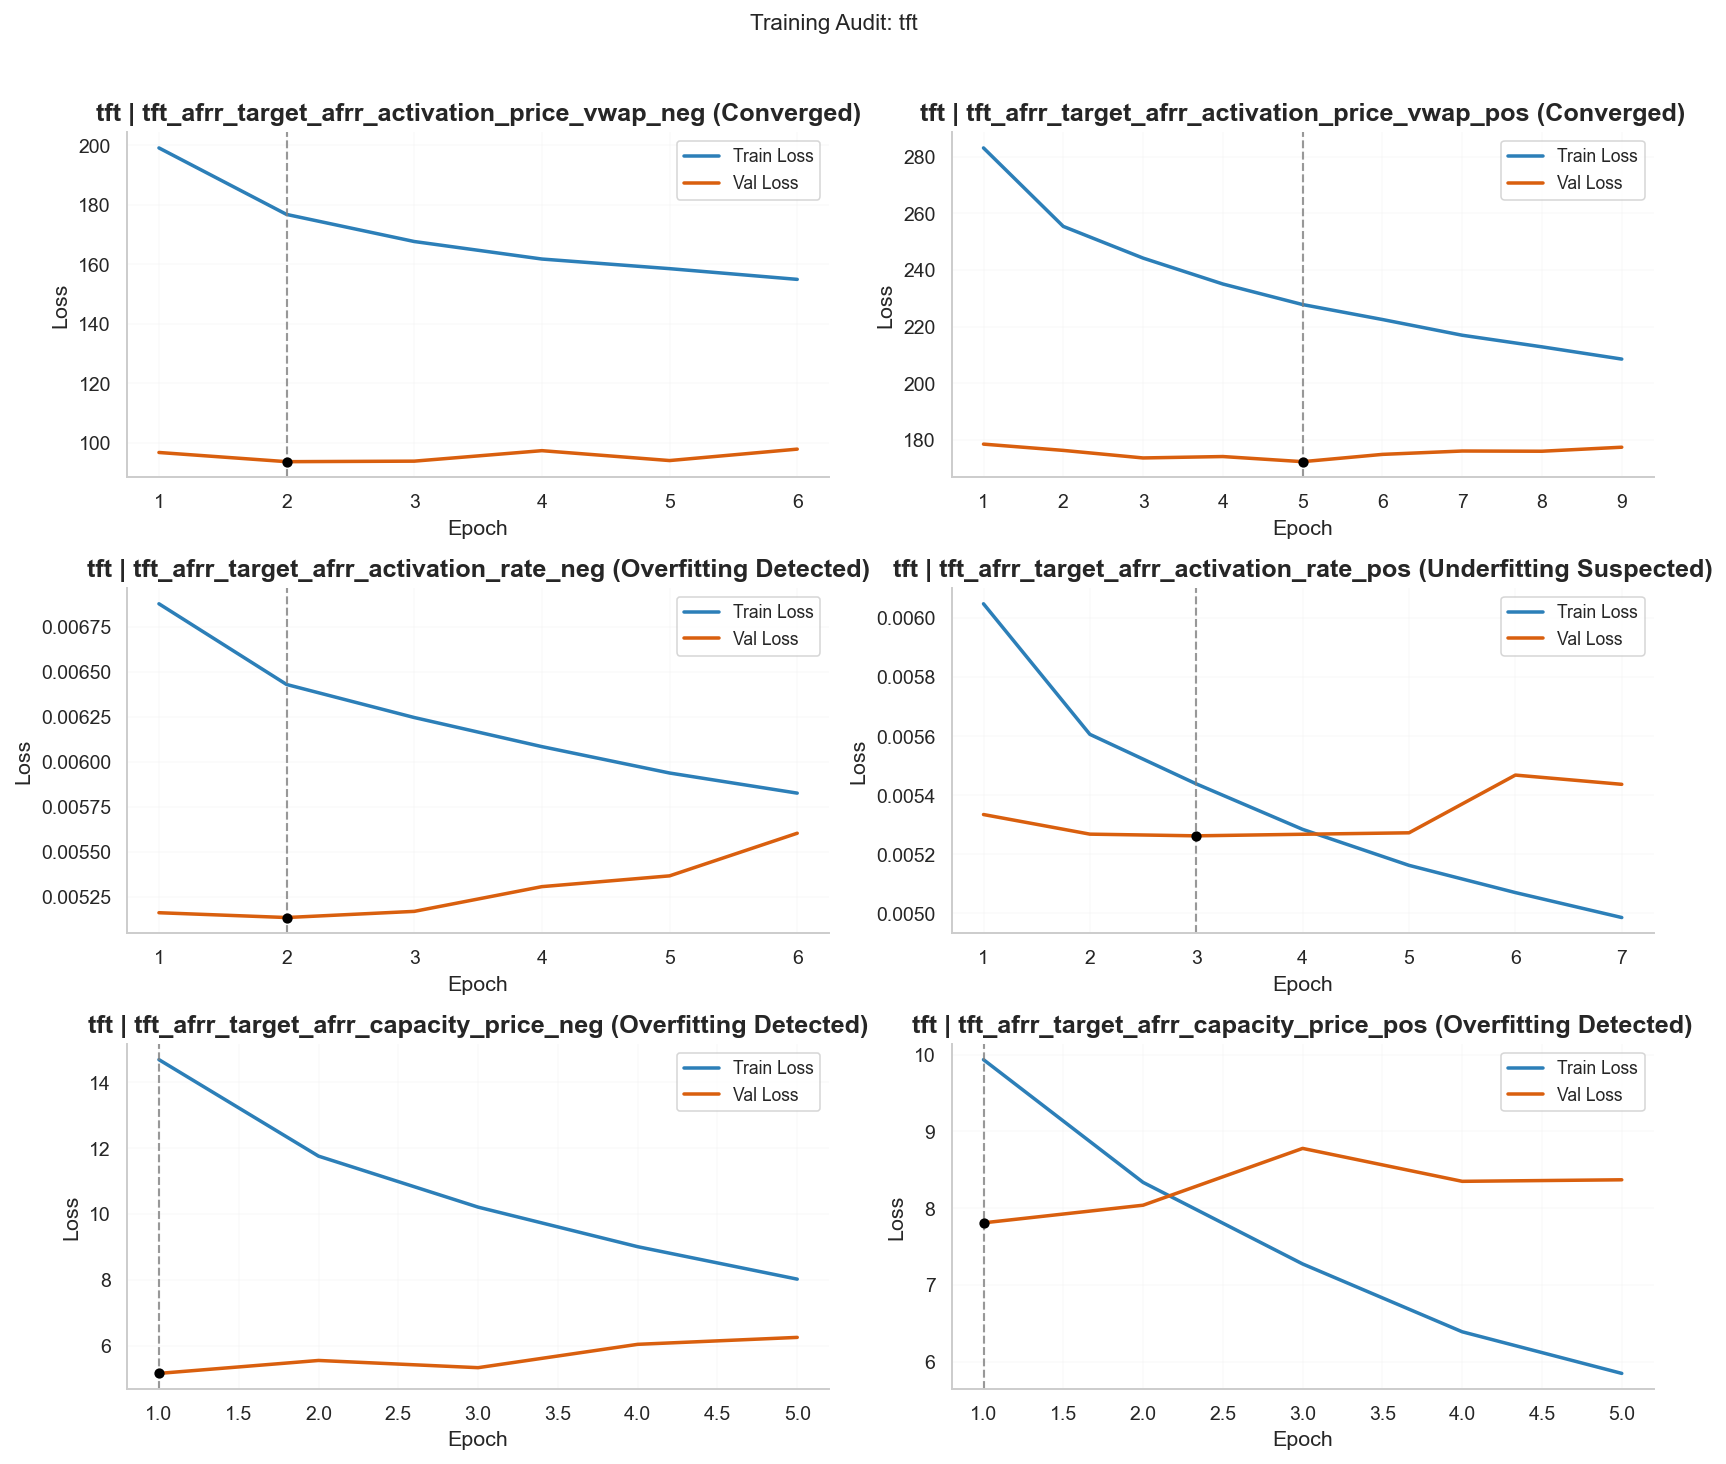

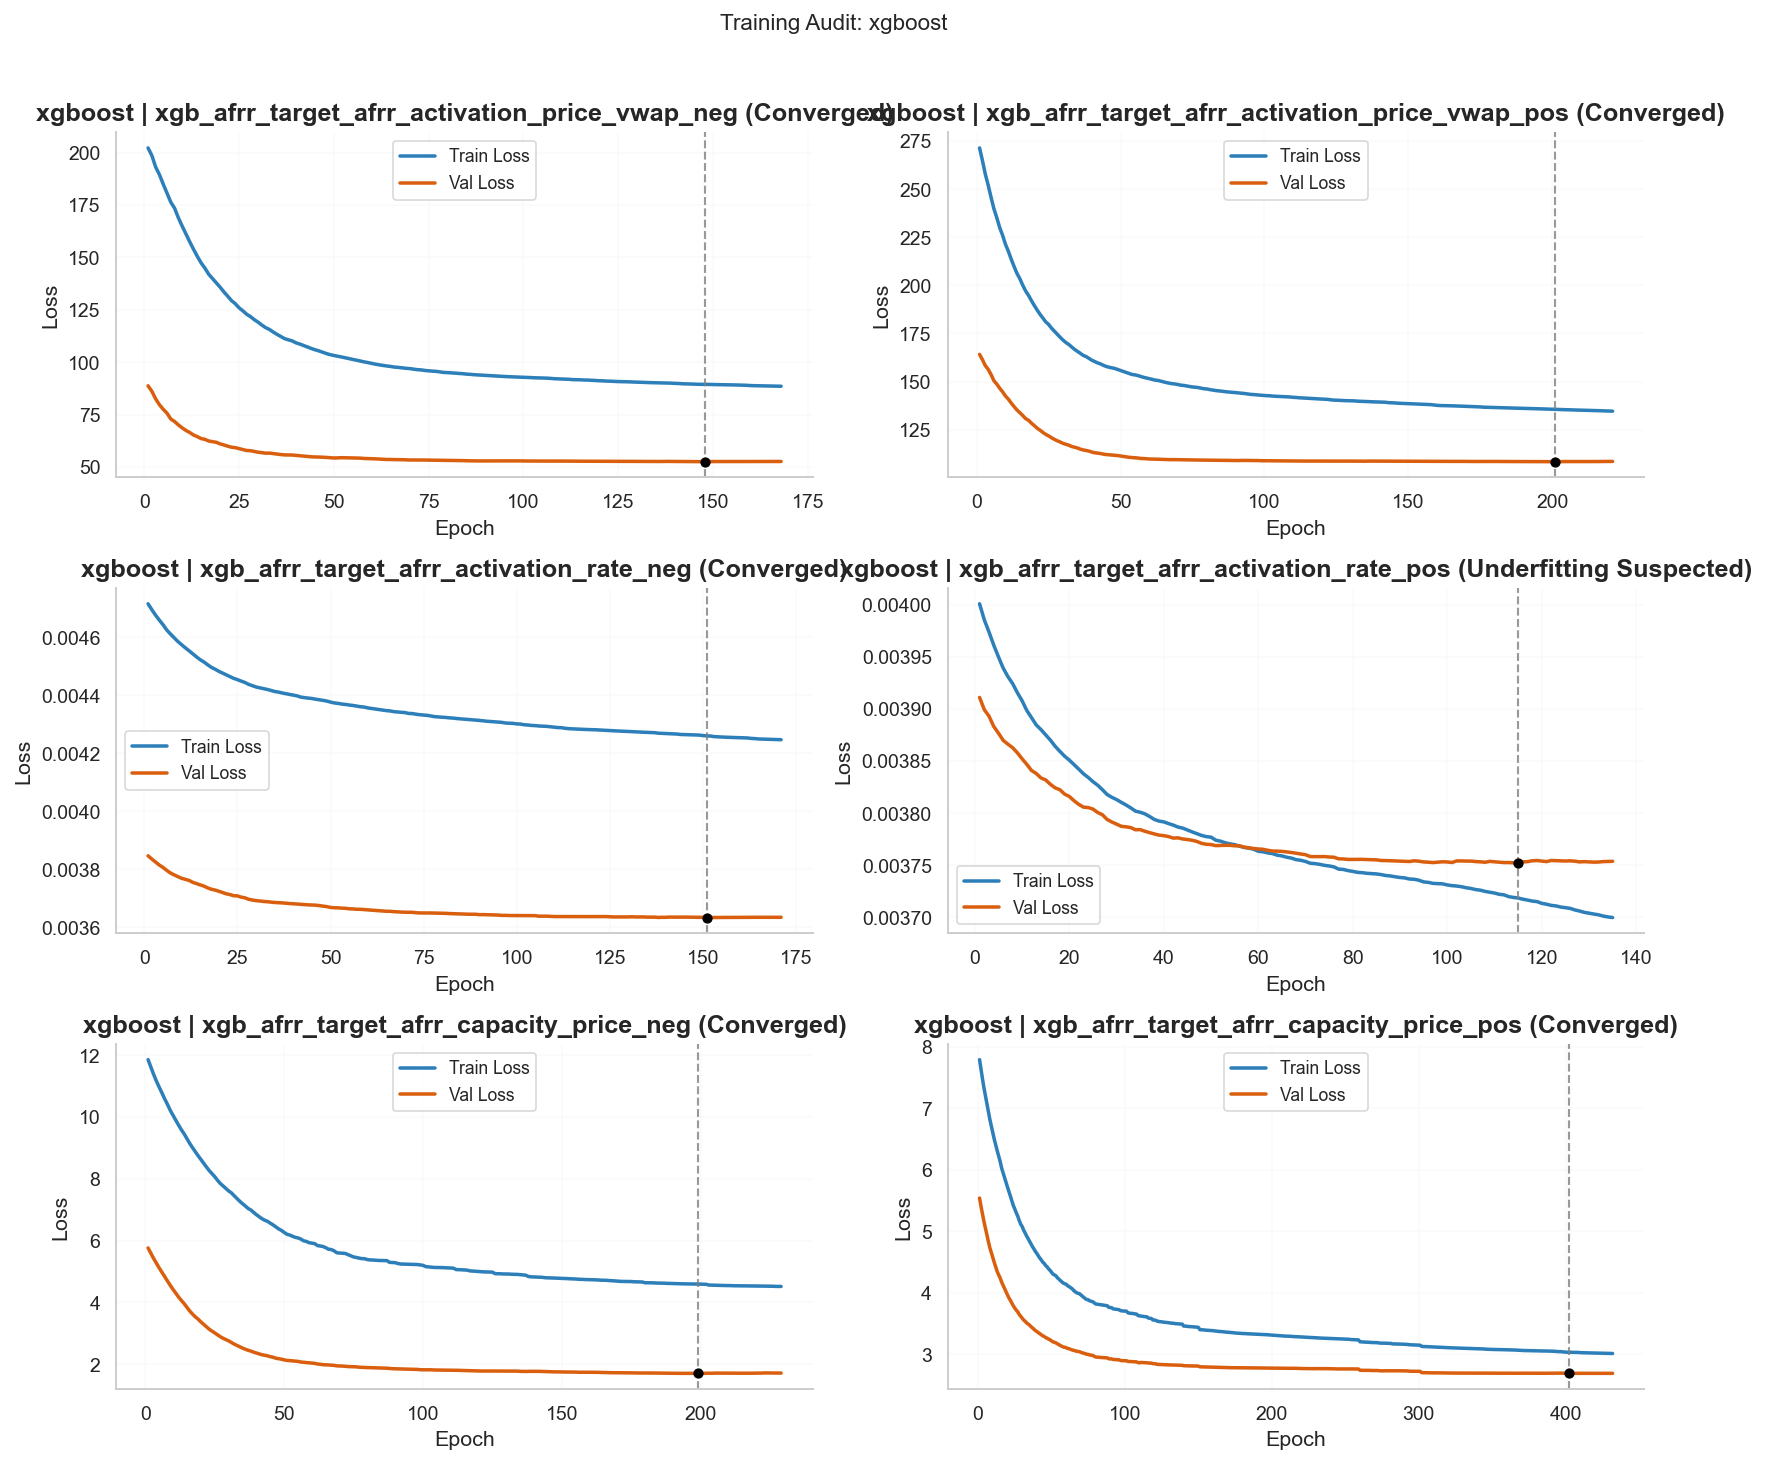

In [16]:
# Plot training vs validation loss curves by model
if summary_df.empty:
    print('No summary rows to plot. Check tag detection table in previous cell.')
else:
    for model in sorted(summary_df['model'].dropna().unique()):
        sub_sum = summary_df[summary_df['model'] == model].sort_values('target_label').reset_index(drop=True)
        n = len(sub_sum)
        ncols = 2
        nrows = int(np.ceil(n / ncols)) if n > 0 else 1
        fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.4 * nrows), sharex=False)
        axes = np.atleast_1d(axes).reshape(nrows, ncols)

        for i, row in sub_sum.iterrows():
            tgt = row['target']
            tgt_label = row.get('target_label', pretty_target_label(tgt))
            run_id = row['run_id']
            r, c = divmod(i, ncols)
            ax = axes[r, c]
            sub = scalars[(scalars['model'] == model) & (scalars['run_id'] == run_id) & (scalars['target'] == tgt)]
            tr = sub[sub['split'] == 'train'].sort_values('step').reset_index(drop=True)
            va = sub[sub['split'] == 'val'].sort_values('step').reset_index(drop=True)

            if tr.empty or va.empty:
                ax.text(0.5, 0.5, 'Missing loss scalars', ha='center', va='center')
                ax.set_title(f"{tgt_label}")
                continue

            tr['epoch'] = np.arange(1, len(tr) + 1)
            va['epoch'] = np.arange(1, len(va) + 1)

            ax.plot(tr['epoch'], tr['value'], label='Train Loss', linewidth=1.8, color='#2C7FB8')
            ax.plot(va['epoch'], va['value'], label='Val Loss', linewidth=1.8, color='#D95F0E')

            best_idx = int(np.argmin(va['value'].to_numpy(dtype=float)))
            best_epoch = int(va.iloc[best_idx]['epoch'])
            best_val = float(va.iloc[best_idx]['value'])
            ax.axvline(best_epoch, color='gray', linestyle='--', linewidth=1.1, alpha=0.8)
            ax.scatter([best_epoch], [best_val], color='black', s=20, zorder=3)

            st = row['status']
            ax.set_title(f"{tgt_label} ({st})")
            ax.set_xlabel('Epoch')
            ax.set_ylabel('Loss')
            ax.legend(loc='best')
            ax.grid(alpha=0.25)

        for j in range(len(sub_sum), nrows * ncols):
            r, c = divmod(j, ncols)
            axes[r, c].axis('off')

        fig.suptitle(f"Training Audit: {pretty_model_label(model)}", y=1.03, fontsize=18, fontweight="bold")
        plt.tight_layout()
        display(fig)
        plt.close(fig)


In [17]:
# Learning-rate schedule audit by model
lr_df = scalars[scalars['split'] == 'lr'].copy() if not scalars.empty else pd.DataFrame()
if lr_df.empty:
    print('No learning-rate scalar found in logs.')
else:
    for model in sorted(lr_df['model'].dropna().unique()):
        mdf = lr_df[lr_df['model'] == model].copy()
        targets = sorted(mdf['target'].unique(), key=pretty_target_label)
        n = len(targets)
        ncols = 2
        nrows = int(np.ceil(n / ncols)) if n > 0 else 1
        fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.0 * nrows), sharex=False)
        axes = np.atleast_1d(axes).reshape(nrows, ncols)

        for i, tgt in enumerate(targets):
            r, c = divmod(i, ncols)
            ax = axes[r, c]
            sub = mdf[mdf['target'] == tgt].sort_values('step').reset_index(drop=True)
            sub['epoch'] = np.arange(1, len(sub) + 1)
            ax.plot(sub['epoch'], sub['value'], color='#238B45', linewidth=1.8)
            ax.set_title(pretty_target_label(tgt))
            ax.set_xlabel('Epoch')
            ax.set_ylabel('Learning Rate')
            ax.grid(alpha=0.25)

        for j in range(n, nrows * ncols):
            r, c = divmod(j, ncols)
            axes[r, c].axis('off')

        fig.suptitle(f"LR Audit: {pretty_model_label(model)}", y=1.03, fontsize=18, fontweight="bold")
        plt.tight_layout()
        display(fig)
        plt.close(fig)


No learning-rate scalar found in logs.


In [18]:
# JSON-ready audit export for appendix
out = {
    'models': sorted(summary_df['model'].dropna().unique().tolist()) if not summary_df.empty else [],
    'n_targets': int(len(summary_df)),
    'targets': summary_df.to_dict(orient='records'),
}

out_path = REPO_ROOT / 'data/reports/model_audit/training_performance_audit_all_models.json'
out_path.parent.mkdir(parents=True, exist_ok=True)
out_path.write_text(json.dumps(out, indent=2), encoding='utf-8')
print('Wrote:', out_path)


Wrote: /Users/leori/Code/energyTrading/data/reports/model_audit/training_performance_audit_all_models.json
